# Building a Movie Recommendation System
### By : Madison Berrios

# This file contains Phase 1

# **Data Loading & Exploratory Data Analysis**

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Load the dataset

In [ ]:
columns = ["userId", "movieId", "movie_categoryId", "reviewId", "movieRating", "reviewDate"]

ratings = pd.read_csv(
    "/content/drive/MyDrive/movie_recommendation_system/movie-ratings.txt",
    names=columns,
    header=None
)

ratings.head(100)

,userId,movieId,movie_categoryId,reviewId,movieRating,reviewDate
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12
...,...,...,...,...,...,...
95,19,4,1,96,5,2001-04-27
96,94,4,1,97,5,2001-04-30
97,95,4,1,98,5,2001-10-20
98,96,4,1,99,5,2002-03-08


# 2. Basic Statistics

In [ ]:
num_users = ratings["userId"].nunique()
num_movies = ratings["movieId"].nunique()
num_ratings = len(ratings)

possible = num_users * num_movies
sparsity = 1 - (num_ratings / possible)

print("Users:", num_users)
print("Movies:", num_movies)

Users: 17615
Movies: 16121


- There's a total of 17,615 user's in the dataset.
- There's a total of 16,121 movies.
- There's a total of 72,665 rating's from 17,615 user's.


# Overall Summary Statistic of the Dataset

In [ ]:
ratings.describe()

,userId,movieId,movie_categoryId,reviewId,movieRating
count,72665.000000,72665.000000,72665.000000,72665.000000,72665.000000
mean,4279.437597,8076.878786,12.659300,36333.000000,4.072910
std,4620.200449,4397.176683,4.158915,20976.722992,1.081442
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,857.000000,4632.000000,11.000000,18167.000000,4.000000
50%,2102.000000,7623.000000,14.000000,36333.000000,4.000000
75%,6568.000000,12105.000000,16.000000,54499.000000,5.000000
max,17615.000000,16121.000000,17.000000,72665.000000,5.000000


# 3. Rating Distribution

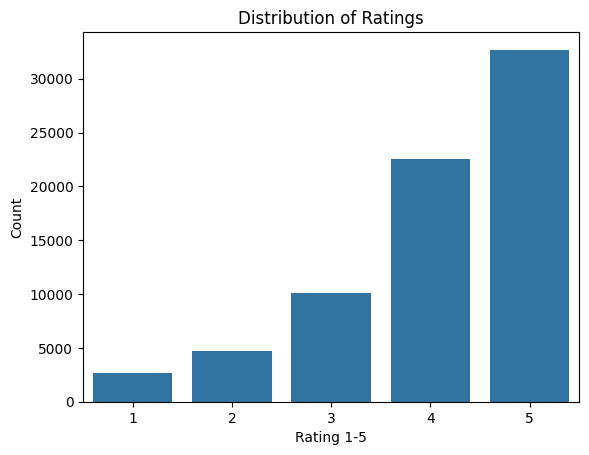

In [ ]:
sns.countplot(x="movieRating", data=ratings)
plt.title("Distribution of Ratings")
plt.xlabel("Rating 1-5")
plt.ylabel("Count")
plt.show()

- The rating go from 1 - 5: 1 meaning bad, and 5 meaning very good.
- This visual shows a left skewed distribution. The majority of rating were a 5. mean < median < mode .

# 4. Rating Per User and Rating per Movie

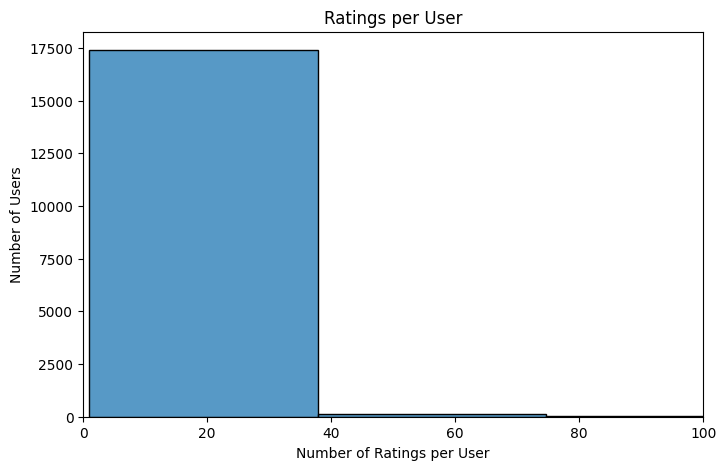

In [ ]:
ratings_per_user = ratings.groupby("userId").size()

plt.figure(figsize=(8,5))

sns.histplot(ratings_per_user, bins=30)

plt.xlim(0, 100)

plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("Ratings per User")

plt.show()

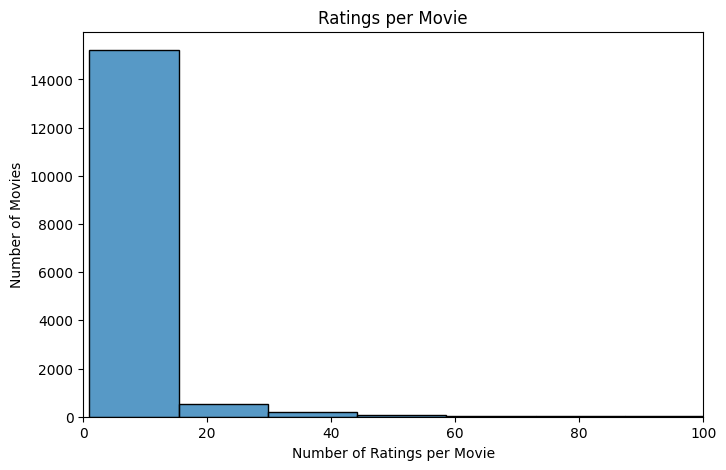

In [ ]:
ratings_per_movie = ratings.groupby("movieId").size()

plt.figure(figsize=(8,5))
sns.histplot(ratings_per_movie, bins=30)

plt.xlim(0, 100)
plt.xlabel("Number of Ratings per Movie")
plt.ylabel("Number of Movies")
plt.title("Ratings per Movie")

plt.show()

- Both the ratings per user and ratings per movie distributions exhibit a long-tail pattern. Most users rate only a small number of movies, and most movies receive only a few ratings. Only a small number of users and movies contribute to a large portion of the interactions. This leads to a sparse dataset, where many user-movie combinations have no ratings.

# 5. Data Cleaning
- I would remove userId and reviewId
- Check for missing values --> filled with mean

# Check for missing values.  

In [ ]:
ratings.isnull().sum()

,0
userId,0
movieId,0
movie_categoryId,0
reviewId,0
movieRating,0
reviewDate,0


- Dataset does not have any null values no need to fill them with the mean.

# Check for duplicates

In [ ]:
ratings.duplicated().sum()

np.int64(0)

- There's no duplicates.

# Check rating range

In [ ]:
ratings["movieRating"].unique()

array([5, 4, 3, 1, 2])

- No invalid values --> Clean dataset.

# Drop features reviewId, and reviewDate

In [ ]:
ratings = ratings.drop(columns=["reviewId", "reviewDate"])

- Columns that were not relevant for the recommendation task, such as reviewId and reviewDate were removed. The userId, movieId, and movieRating columns were retained as they are essential for building the recommendation system.